# MLP
- Liad Mandil, 315096073
- Maxim Prokopchuk, 337875397

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay, roc_curve, auc
)


--------------------

## Load Data

In [2]:
spaceship_data = pd.read_csv('final_data.csv')

## split to x and y

In [3]:
y = spaceship_data["Transported"].astype(int)
x = spaceship_data.drop(columns=["Transported"])

## Train-Test Split

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## בדיקת ערכי ההייפר פרמטרים

In [6]:
results = []
best_score = 0
best_params_mlp = None

#### בסיס לבדיקת הייפר פרמטרים

In [7]:
# baseline "fixed" setup (we'll change one thing at a time later)
baseline_hidden = (64,)
baseline_alpha = 1e-4
baseline_activation = "relu"

mlp_base = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=baseline_hidden,
        alpha=baseline_alpha,
        activation=baseline_activation,
    ))
])

fold_scores = cross_val_score(
    mlp_base, x_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1
)

print("MLP Baseline")
print("Fold accuracies (%):", np.round(100 * fold_scores, 2))
print(f"Mean CV accuracy: {100 * fold_scores.mean():.2f}% | Std: {100 * fold_scores.std():.2f}%")


MLP Baseline
Fold accuracies (%): [78.91 78.91 80.2  78.89 79.84]
Mean CV accuracy: 79.35% | Std: 0.56%


#### hidden_layer_sizes

In [8]:
results_hidden = []
best_hidden = None
best_hidden_score = -1

hidden_list = [(16,), (32,), (64,), (128,), (64, 32), (128, 64), (128, 64, 32)]

for h in hidden_list:
    mlp_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=h,
            alpha=baseline_alpha,
            activation=baseline_activation,
            solver="adam",
            random_state=42,
            max_iter=2000,
            early_stopping=True,
            n_iter_no_change=20,
            validation_fraction=0.1
        ))
    ])

    fold_scores = cross_val_score(
        mlp_pipe, x_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1
    )
    mean_score = fold_scores.mean()

    results_hidden.append({
        "hidden_layer_sizes": str(h),
        "cv_mean": mean_score,
        "cv_std": fold_scores.std()
    })

    if mean_score > best_hidden_score:
        best_hidden_score = mean_score
        best_hidden = h





In [9]:
results_hidden_df = pd.DataFrame(results_hidden).sort_values("cv_mean", ascending=False)
display(results_hidden_df.round(4))

print("Best hidden_layer_sizes:", best_hidden)
print(f"Best CV accuracy (hidden sweep): {100 * best_hidden_score:.2f}%")

,hidden_layer_sizes,cv_mean,cv_std
5,"(128, 64)",0.7942,0.0012
6,"(128, 64, 32)",0.7929,0.0061
2,"(64,)",0.7923,0.0101
4,"(64, 32)",0.7916,0.0106
0,"(16,)",0.7913,0.0107
3,"(128,)",0.7901,0.0084
1,"(32,)",0.7895,0.0054


Best hidden_layer_sizes: (128, 64)
Best CV accuracy (hidden sweep): 79.42%


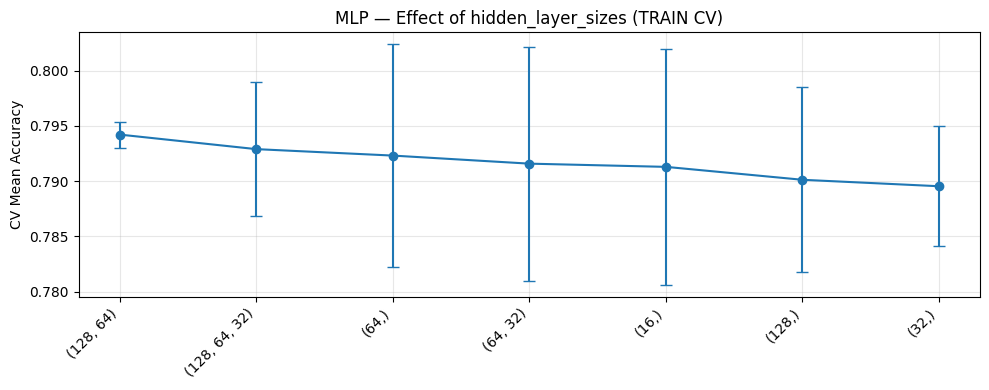

In [10]:
tmp = results_hidden_df.copy()
x_pos = np.arange(len(tmp))

plt.figure(figsize=(10,4))
plt.errorbar(
    x_pos,
    tmp["cv_mean"],
    yerr=tmp["cv_std"],
    fmt="o-",
    capsize=4
)
plt.xticks(x_pos, tmp["hidden_layer_sizes"], rotation=45, ha="right")
plt.ylabel("CV Mean Accuracy")
plt.title("MLP — Effect of hidden_layer_sizes (TRAIN CV)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### Alpha

In [11]:
results_alpha = []
best_alpha = None
best_alpha_score = -1

alpha_list = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

for a in alpha_list:
    mlp_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=best_hidden,
            alpha=a,
            activation=baseline_activation,
            solver="adam",
            random_state=42,
            max_iter=2000,
            early_stopping=True,
            n_iter_no_change=20,
            validation_fraction=0.1
        ))
    ])

    fold_scores = cross_val_score(
        mlp_pipe, x_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1
    )
    mean_score = fold_scores.mean()

    results_alpha.append({
        "alpha": a,
        "cv_mean": mean_score,
        "cv_std": fold_scores.std()
    })

    if mean_score > best_alpha_score:
        best_alpha_score = mean_score
        best_alpha = a




In [12]:
results_alpha_df = pd.DataFrame(results_alpha).sort_values("cv_mean", ascending=False)
display(results_alpha_df.round(4))

print("Best alpha:", best_alpha)
print(f"Best CV accuracy (alpha sweep): {100 * best_alpha_score:.2f}%")

,alpha,cv_mean,cv_std
4,0.0100,0.7964,0.0023
0,0.0000,0.7960,0.0047
1,0.0000,0.7947,0.0024
2,0.0001,0.7942,0.0012
3,0.0010,0.7938,0.0032
5,0.1000,0.7914,0.0089


Best alpha: 0.01
Best CV accuracy (alpha sweep): 79.64%


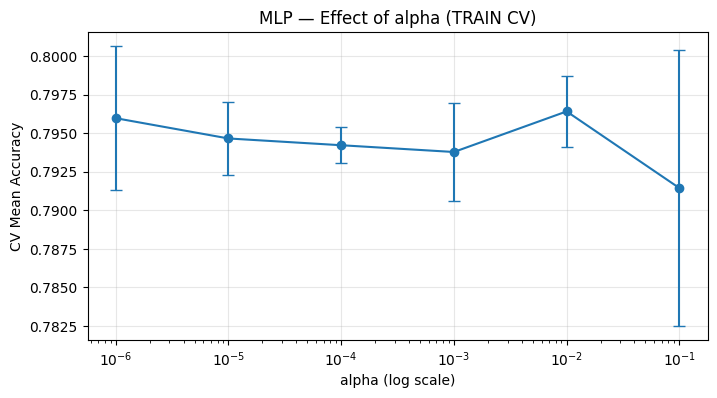

In [13]:
tmp = results_alpha_df.sort_values("alpha")

plt.figure(figsize=(8,4))
plt.errorbar(
    tmp["alpha"],
    tmp["cv_mean"],
    yerr=tmp["cv_std"],
    fmt="o-",
    capsize=4
)
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("CV Mean Accuracy")
plt.title("MLP — Effect of alpha (TRAIN CV)")
plt.grid(alpha=0.3)
plt.show()


#### Activation

In [14]:
results_act = []
best_act = None
best_act_score = -1

activation_list = ["relu", "tanh"]

for act in activation_list:
    mlp_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=best_hidden,
            alpha=best_alpha,
            activation=act,
            solver="adam",
            random_state=42,
            max_iter=2000,
            early_stopping=True,
            n_iter_no_change=20,
            validation_fraction=0.1
        ))
    ])

    fold_scores = cross_val_score(
        mlp_pipe, x_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1
    )
    mean_score = fold_scores.mean()

    results_act.append({
        "activation": act,
        "cv_mean": mean_score,
        "cv_std": fold_scores.std()
    })

    if mean_score > best_act_score:
        best_act_score = mean_score
        best_act = act



In [15]:

results_act_df = pd.DataFrame(results_act).sort_values("cv_mean", ascending=False)
display(results_act_df.round(4))

print("Best activation:", best_act)
print(f"Best CV accuracy (activation sweep): {100*best_act_score:.2f}%")

,activation,cv_mean,cv_std
1,tanh,0.7966,0.0069
0,relu,0.7964,0.0023


Best activation: tanh
Best CV accuracy (activation sweep): 79.66%


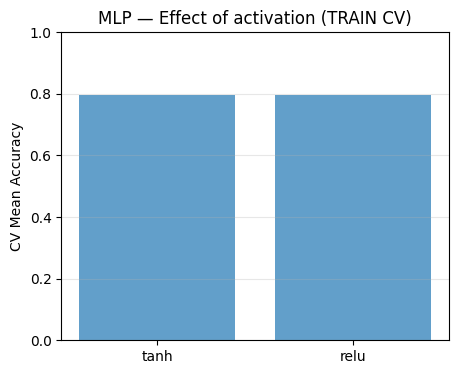

In [16]:
plt.figure(figsize=(5,4))
plt.bar(results_act_df["activation"], results_act_df["cv_mean"], alpha=0.7)
plt.ylim(0, 1)
plt.ylabel("CV Mean Accuracy")
plt.title("MLP — Effect of activation (TRAIN CV)")
plt.grid(axis="y", alpha=0.3)
plt.show()


#### best model

In [17]:
best_params_mlp = {
    "hidden_layer_sizes": best_hidden,
    "alpha": best_alpha,
    "activation": best_act
}

print("Best MLP params:", best_params_mlp)

best_MLP = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=best_params_mlp["hidden_layer_sizes"],
        alpha=best_params_mlp["alpha"],
        activation=best_params_mlp["activation"],
    ))
])

best_MLP.fit(x_train, y_train)

Best MLP params: {'hidden_layer_sizes': (128, 64), 'alpha': 0.01, 'activation': 'tanh'}


c:\Users\Liad M\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(activation='tanh', alpha=0.01,
                               hidden_layer_sizes=(128, 64)))])

In [18]:
best_mlp_params = {
    "hidden_layer_sizes": (128, 64),
    "alpha": 0.01,
    "activation": "tanh"
}

mlp_params_df = pd.DataFrame(
    list(best_mlp_params.items()),
    columns=["Parameter", "Value"]
)

display(mlp_params_df)

,Parameter,Value
0,hidden_layer_sizes,"(128, 64)"
1,alpha,0.01
2,activation,tanh


## Results

In [19]:
y_pred_train = best_MLP.predict(x_train)
acc = accuracy_score(y_train, y_pred_train)

print("="*40)
print("BEST MLP — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {acc*100:.2f}%")
print("="*40)

BEST MLP — TRAIN SET PERFORMANCE
Accuracy : 90.92%


#### Confusion Matrix

<Figure size 500x500 with 0 Axes>

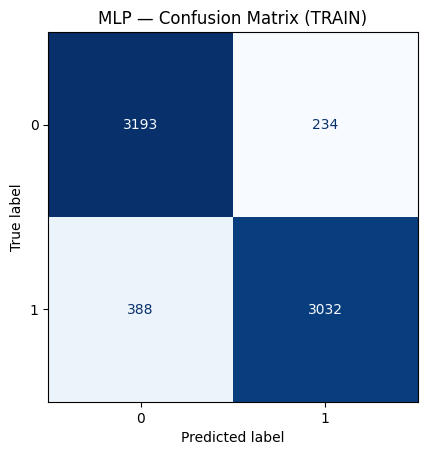

In [20]:
plt.figure(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_pred_train,
    cmap="Blues",
    colorbar=False
)

plt.title("MLP — Confusion Matrix (TRAIN)")
plt.show()

In [21]:
acc = accuracy_score(y_train, y_pred_train)
prec = precision_score(y_train, y_pred_train)
rec = recall_score(y_train, y_pred_train)
f1 = f1_score(y_train, y_pred_train)

metrics_df = pd.DataFrame([{
    "model": "MLP",
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1_score": f1
}])

display(metrics_df.round(4))

print("\nClassification Report (TRAIN):")
print(classification_report(y_train, y_pred_train))

,model,accuracy,precision,recall,f1_score
0,MLP,0.9092,0.9284,0.8865,0.907



Classification Report (TRAIN):
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      3427
           1       0.93      0.89      0.91      3420

    accuracy                           0.91      6847
   macro avg       0.91      0.91      0.91      6847
weighted avg       0.91      0.91      0.91      6847



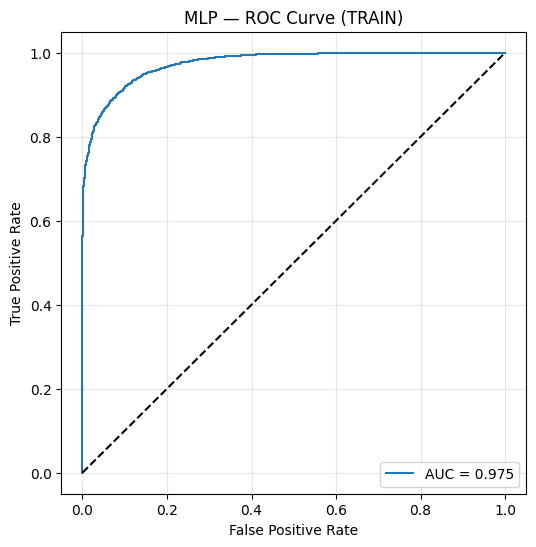

In [22]:
y_prob_train = best_MLP.predict_proba(x_train)[:, 1]

fpr, tpr, thresholds = roc_curve(y_train, y_prob_train)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MLP — ROC Curve (TRAIN)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()